In [23]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [24]:
words = open('names.txt','r').read().splitlines()

In [25]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}  
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
# print(itos)

In [26]:
vocab_size

27

In [27]:
g = torch.Generator(device=device).manual_seed(2147483647)

In [28]:

block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    return X, Y

random.seed(47)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtes, Ytes = build_dataset(words[n2:])

In [29]:
Ytr[0]

tensor(11, device='cuda:0')

In [30]:
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f"{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | max diff: {maxdiff}")

In [31]:
n_embd = 10
n_hidden = 64

g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g, device=device)

#layer1
W1 = torch.randn((n_embd*block_size, n_hidden), generator=g, device=device)*((5/3)/((n_embd*block_size)**0.5))
b1 = torch.randn(n_hidden, generator=g, device=device) * 0.1

#layer2
w2 = torch.randn((n_hidden, vocab_size), generator=g, device=device)*0.1
b2 = torch.randn((vocab_size,), generator=g, device=device)*0.1

#batch_normalization parameters
bngain = torch.randn((1, n_hidden), device=device)*0.1 + 1.0
bnbias = torch.randn((1, n_hidden), device=device)*0.1

parameters = [C, W1, b1, w2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

4137


In [32]:
batch_size = 32
n = batch_size

ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device=device)
Xb, Yb = Xtr[ix], Ytr[ix]

In [33]:
ix

tensor([ 71595,  34480, 129268, 112500, 166236, 148122, 116200, 144530, 105578,
         76929, 140311,  21140, 139822, 121790, 102735,  94976, 171190,  81608,
        139863,  28502,  88872, 135448,  40541,  49666, 106869, 181962,  88735,
        116282,  34368,  41126,  30150, 154431], device='cuda:0')

In [34]:
embcat.shape

torch.Size([32, 30])

In [35]:
emb = C[Xb]                                                      #look up the embeddings for the batch, resulting in a (batch_size, block_size, n_embd) tensor
embcat = emb.view(emb.shape[0], -1)                              # concatenate the embeddings into a (batch_size, block_size*n_embd) tensor

hprebn = embcat @ W1 + b1                                        # linear layer, resulting in (batch_size, n_hidden) tensor

bnmeani = 1/n * hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1) * (bndiff2).sum(0, keepdim=True)
bnvar_inv = 1.0 / (bnvar + 1e-5)**0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias

h = torch.tanh(hpreact)

logits = h @ w2 + b2
loss_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - loss_maxes
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim=True)
counts_sum_inv = (counts_sum**-1)
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

for p in parameters:
    p.grad = None

for t in [logprobs, probs, counts_sum_inv, counts_sum, counts, norm_logits, loss_maxes, logits, w2, b2, h, hpreact, bnraw, bnvar_inv, bnvar, bndiff2, bndiff, bnmeani]:
    t.retain_grad()
loss.backward()
loss

tensor(3.2909, device='cuda:0', grad_fn=<NegBackward0>)

In [36]:
bngain.shape

torch.Size([1, 64])

In [37]:
bnvar_inv.shape, bndiff.shape, dbnraw.shape

(torch.Size([1, 64]), torch.Size([32, 64]), torch.Size([32, 64]))

In [38]:

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n

dprob = dlogprobs * (probs**-1) 
dcounts_sum_inv = (dprob*counts).sum(1, keepdim=True)
dcounts_sum = dcounts_sum_inv * (-counts_sum**-2)
dcounts = dprob * counts_sum_inv + dcounts_sum
dnorm_logits = dcounts * norm_logits.exp()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits = dnorm_logits + F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
dh = dlogits @ w2.T
dw2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1.0 - h**2) * dh
dbngain = (bnraw * hpreact.grad).sum(0, keepdim=True)
dbnbias = hpreact.grad.sum(0, keepdim=True)
dbnraw = bngain * hpreact.grad
dbnvar_inv = (dbnraw * bndiff).sum(0, keepdim=True)
dbnvar = dbnvar_inv * (-0.5 / (bnvar + 1e-5)**1.5)
dbndiff2 = None
dbndiff = None
dbnmeani = None

cmp("dlogprobs", dlogprobs, logprobs)
cmp("dprod", dprob, probs)
cmp("dcounts_sum_inv", dcounts_sum_inv, counts_sum_inv)
cmp("dcounts_sum", dcounts_sum, counts_sum)
cmp("counts", dcounts, counts)
cmp("dnorm_logits", dnorm_logits, norm_logits)
cmp("dlogit_maxes", dlogit_maxes, loss_maxes)
cmp("dlogits", dlogits, logits)
cmp("dh", dh, h)
cmp("dw2", dw2, w2)
cmp("db2", db2, b2)
cmp("hpreact", dhpreact, hpreact)
cmp("dbngain", dbngain, bngain)
cmp("dbnbias", dbnbias, bnbias)
cmp("dbnraw", dbnraw, bnraw)
cmp("dbnvar_inv", dbnvar_inv, bnvar_inv)
cmp("dbnvar", dbnvar, bnvar)

dlogprobs       | exact: True  | approximate: True  | max diff: 0.0
dprod           | exact: True  | approximate: True  | max diff: 0.0
dcounts_sum_inv | exact: True  | approximate: True  | max diff: 0.0
dcounts_sum     | exact: True  | approximate: True  | max diff: 0.0
counts          | exact: True  | approximate: True  | max diff: 0.0
dnorm_logits    | exact: True  | approximate: True  | max diff: 0.0
dlogit_maxes    | exact: True  | approximate: True  | max diff: 0.0
dlogits         | exact: True  | approximate: True  | max diff: 0.0
dh              | exact: True  | approximate: True  | max diff: 0.0
dw2             | exact: True  | approximate: True  | max diff: 0.0
db2             | exact: True  | approximate: True  | max diff: 0.0
hpreact         | exact: False | approximate: True  | max diff: 4.656612873077393e-10
dbngain         | exact: True  | approximate: True  | max diff: 0.0
dbnbias         | exact: True  | approximate: True  | max diff: 0.0
dbnraw          | exact: True 

In [39]:
w2.shape

torch.Size([64, 27])

In [40]:
h.sum(0, keepdim=True)

tensor([[-1.5831, -1.7593, -0.7508, -0.0776, -0.0261,  1.2653, -2.7240, -0.7043,
          4.0948,  0.3685, -5.1310, -0.5928,  0.6450,  0.4188,  0.8610,  0.4373,
          3.9400, -1.7044, -0.4748, -2.5700,  0.2876,  1.1953,  0.7572,  1.1562,
          0.7513,  0.6604,  0.0702, -2.1301, -1.8597, -2.7517,  3.2536,  4.0336,
          0.4217,  0.7232, -0.2550,  2.2697,  0.4020,  2.7268, -2.7529,  0.5537,
         -0.3641, -0.1325, -2.2767,  1.1217, -1.0905,  5.1277, -0.0229,  0.8114,
         -3.0859,  2.0520,  2.5763,  3.4122, -3.0447,  0.8641, -2.4479, -0.9080,
         -2.9829,  0.8916, -1.1682, -2.4165, -2.7877,  3.0200,  1.0070,  1.0360]],
       device='cuda:0', grad_fn=<SumBackward1>)

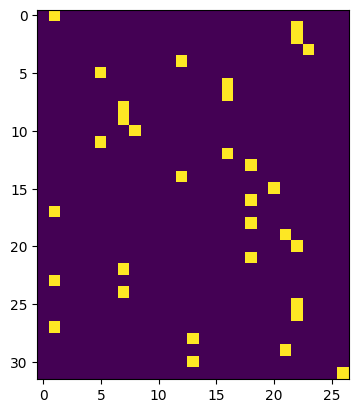

In [41]:
plt.imshow(F.one_hot(logits.max(1).indices.cpu(), num_classes=logits.shape[1]))

In [42]:
F.softmax(logits,1)

tensor([[0.0560, 0.0926, 0.0355, 0.0443, 0.0335, 0.0317, 0.0409, 0.0255, 0.0158,
         0.0188, 0.0278, 0.0331, 0.0163, 0.0331, 0.0312, 0.0233, 0.0289, 0.0404,
         0.0771, 0.0563, 0.0372, 0.0430, 0.0455, 0.0266, 0.0515, 0.0162, 0.0179],
        [0.0469, 0.0222, 0.0278, 0.0213, 0.0364, 0.0388, 0.0126, 0.0260, 0.0137,
         0.0311, 0.0233, 0.0233, 0.0185, 0.0233, 0.0170, 0.0114, 0.0719, 0.0391,
         0.0747, 0.0794, 0.0351, 0.0254, 0.1342, 0.0566, 0.0323, 0.0302, 0.0275],
        [0.0282, 0.0205, 0.0265, 0.0212, 0.0256, 0.0543, 0.0349, 0.0140, 0.0202,
         0.0198, 0.0344, 0.0305, 0.0305, 0.0363, 0.0218, 0.0735, 0.0540, 0.0293,
         0.0360, 0.0350, 0.0419, 0.0207, 0.1708, 0.0636, 0.0259, 0.0171, 0.0131],
        [0.0412, 0.0726, 0.0399, 0.0165, 0.0176, 0.0439, 0.0127, 0.0283, 0.0283,
         0.0738, 0.0265, 0.0344, 0.0272, 0.0307, 0.0246, 0.0163, 0.0491, 0.0558,
         0.0196, 0.0396, 0.0348, 0.0202, 0.0686, 0.0752, 0.0192, 0.0234, 0.0599],
        [0.0381, 0.0181,